In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as LogRegSK
from sklearn.preprocessing import StandardScaler

from metrics.metrics import accuracy_score, log_loss
from classic_ml_models.linear_models import LogisticRegression

np.set_printoptions(suppress=True)

early_stopping_value = 0.000001
num_iterations = 100000
C = 1

X, y = load_breast_cancer(return_X_y=True)


scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
log_reg = LogisticRegression(num_iter=num_iterations, C=C)
log_reg.fit(X_train, y_train)

print(f"Weights: {log_reg.weights}")
print(f"Bias: {log_reg.bias}")
predictions = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Stopped on iteration 249
Weights: [-0.11446293 -0.08318241 -0.11443116 -0.10691415 -0.05319267 -0.07033353
 -0.09235266 -0.1148148  -0.04392204  0.0290711  -0.07905549  0.00481125
 -0.0726569  -0.07111811  0.01249685 -0.01363725 -0.00816733 -0.04744662
  0.01310247  0.02065221 -0.12443906 -0.09592299 -0.12248262 -0.1115675
 -0.07969522 -0.08377584 -0.09693587 -0.12679674 -0.075287   -0.04143166]
Bias: 0.590585058363064
Accuracy: 0.9824561403508771
Logloss: 0.3016799788052124


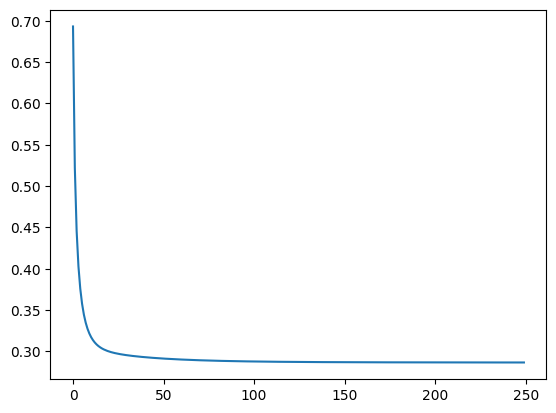

In [27]:
plt.plot(log_reg.losses)

In [28]:
sk_logreg = LogRegSK(max_iter=num_iterations, C=C)
sk_logreg.fit(X_train, y_train)

print(f"Weights: {sk_logreg.coef_}")
print(f"Bias: {sk_logreg.intercept_}")
predictions = sk_logreg.predict(X_test)
probs = sk_logreg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Weights: [[-0.52213045 -0.53658554 -0.4979442  -0.56379712 -0.13460195  0.73756901
  -0.71136223 -0.76950335 -0.07628683  0.35316847 -1.20764229  0.26646079
  -0.74326528 -0.91757362 -0.18015681  0.6672991   0.13674384 -0.39552312
   0.36062184  0.43203303 -0.98028724 -1.32075819 -0.81310456 -0.9717533
  -0.91263827  0.09258914 -0.88766361 -0.95708094 -1.03704807 -0.24200346]]
Bias: [0.24347643]
Accuracy: 0.9649122807017544
Logloss: 0.12110225556045545
